# Project 3: Gradient Descent Visualiser

Implement and visualise gradient descent on
three different loss functions: x², x⁴ - 4x², and a
noisy quadratic. Show the descent path as an
animated scatter on the loss surface. Compare
the effect of three different learning rates (too
small, good, too large).

### Skills: NumPy, Matplotlib animation or multi-plot,gradient math


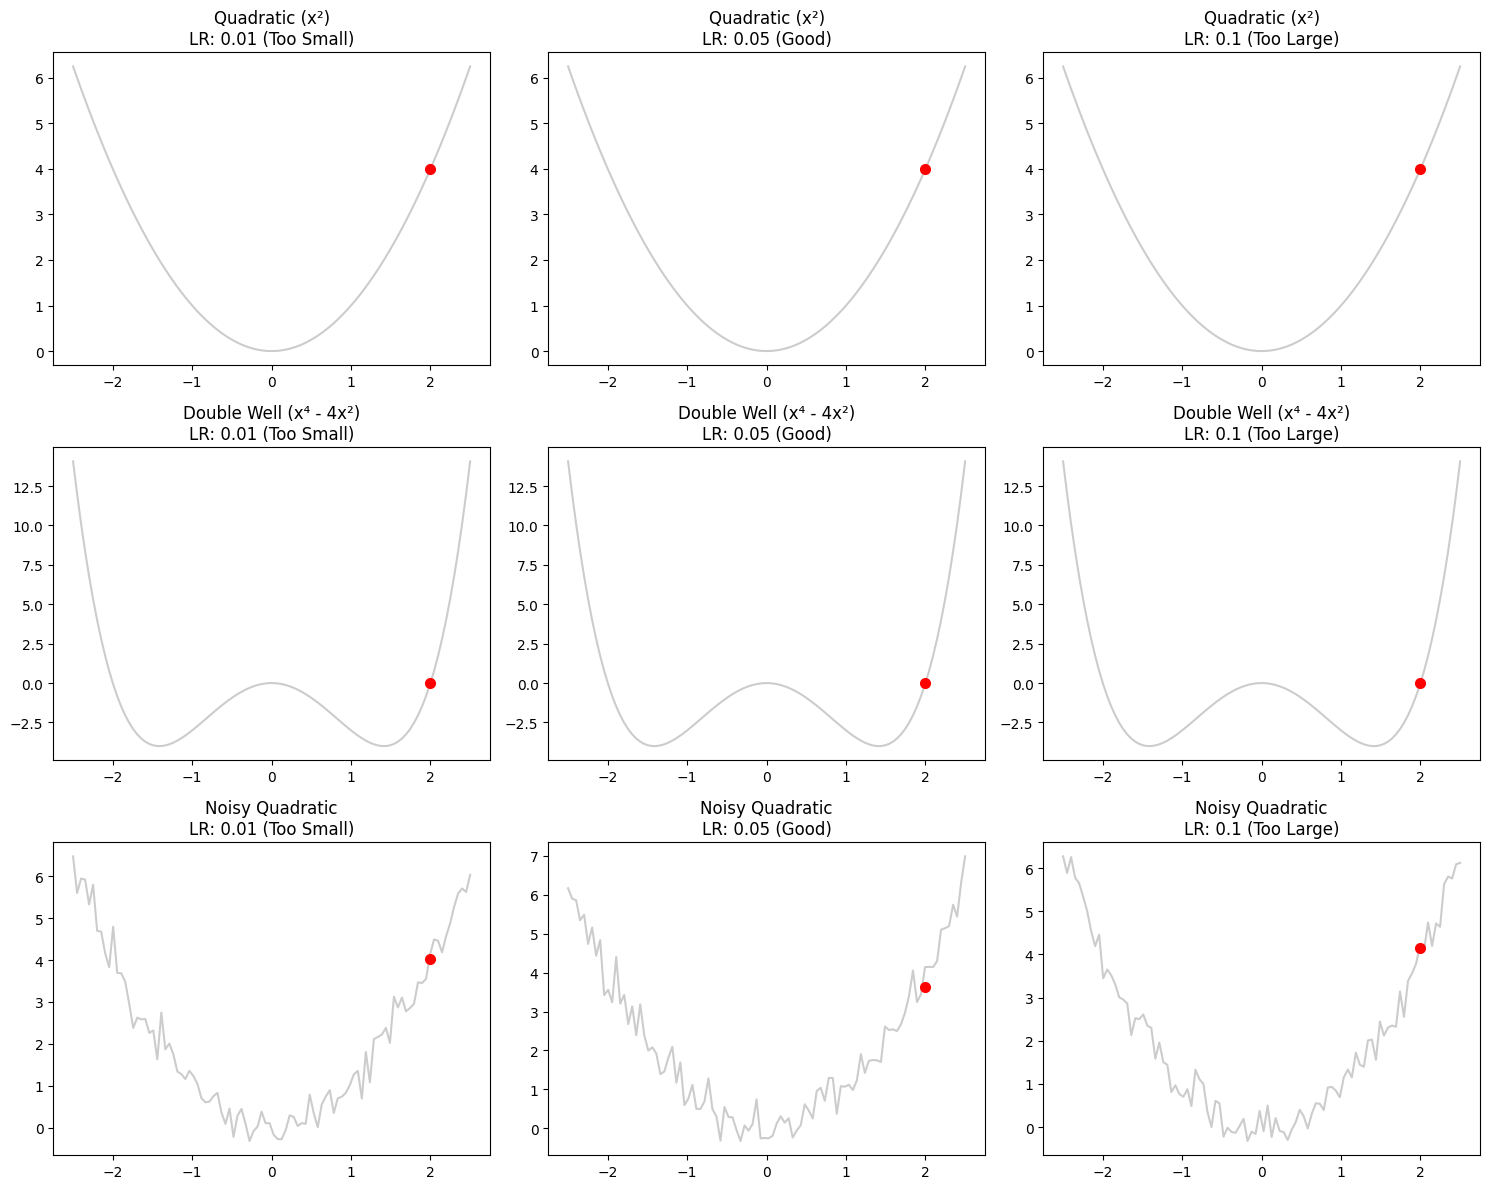

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- 1. MATHEMATICAL DEFINITIONS ---
# We define each function and its derivative (gradient) as standalone functions.

# Loss Function 1: Simple Quadratic
def func_1(x): return x**2
def grad_1(x): return 2*x

# Loss Function 2: Double Well
def func_2(x): return (x**4) - (4*(x**2))
def grad_2(x): return (4*(x**3)) - 8*x

# Loss Function 3: Noisy Quadratic
def func_3(x): 
    # We add a bit of noise to the y-value for the surface
    return x**2 + np.random.normal(0, 0.3, size=x.shape)
def grad_3(x): 
    # We add noise to the gradient calculation to simulate noisy data
    return 2*x + np.random.normal(0, 0.6)

# Lists to make looping through them easier
functions = [func_1, func_2, func_3]
gradients = [grad_1, grad_2, grad_3]
names = ["Quadratic (x²)", "Double Well (x⁴ - 4x²)", "Noisy Quadratic"]

# --- 2. THE OPTIMIZATION PARAMETERS ---
learning_rates = [0.01, 0.05, 0.1] # Small, Good, Large
n_steps = 25
x_start = 2.0

# --- 3. PRE-COMPUTING THE PATHS ---
# We store the results in a nested list: [function_index][lr_index]
all_x_paths = []
all_y_paths = []

for i in range(len(functions)):
    f_paths_x = []
    f_paths_y = []
    
    for lr in learning_rates:
        x_history = [x_start]
        y_history = [functions[i](np.array([x_start]))[0]]
        
        x_current = x_start
        for _ in range(n_steps):
            # The actual Gradient Descent Step:
            step = lr * gradients[i](x_current)
            x_current = x_current - step
            
            x_history.append(x_current)
            f_val = functions[i](np.array([x_current]))[0]
            y_history.append(f_val)
            
        f_paths_x.append(x_history)
        f_paths_y.append(y_history)
        
    all_x_paths.append(f_paths_x)
    all_y_paths.append(f_paths_y)

# --- 4. VISUALIZATION SETUP ---
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
x_range = np.linspace(-2.5, 2.5, 100)

# Objects to update during animation
dots = []
lines = []

for i in range(3): # Loop through functions
    for j in range(3): # Loop through learning rates
        ax = axes[i, j]
        
        # Plot the static background curve
        y_range = functions[i](x_range)
        ax.plot(x_range, y_range, color='black', alpha=0.2, label='Loss Surface')
        
        # Set titles
        lr_status = ["Too Small", "Good", "Too Large"][j]
        ax.set_title(f"{names[i]}\nLR: {learning_rates[j]} ({lr_status})")
        
        # Create the "empty" plot objects that will move
        dot, = ax.plot([], [], 'ro', markersize=7)
        line, = ax.plot([], [], 'r-', alpha=0.5)
        
        dots.append(dot)
        lines.append(line)

# --- 5. THE ANIMATION UPDATE FUNCTION ---
def update(frame):
    # This function runs for every frame of the animation
    plot_idx = 0
    for i in range(3):
        for j in range(3):
            # Get the pre-computed coordinates
            this_x = all_x_paths[i][j][frame]
            this_y = all_y_paths[i][j][frame]
            
            full_path_x = all_x_paths[i][j][:frame+1]
            full_path_y = all_y_paths[i][j][:frame+1]
            
            # Update the red dot and the trail line
            dots[plot_idx].set_data([this_x], [this_y])
            lines[plot_idx].set_data(full_path_x, full_path_y)
            
            plot_idx += 1
            
    return dots + lines

# Generate animation
ani = FuncAnimation(fig, update, frames=n_steps, interval=200, blit=True)

plt.tight_layout()
plt.show()